       Date          SPX        GLD        USO     SLV   EUR/USD
0  1/2/2008  1447.160034  84.860001  78.470001  15.180  1.471692
1  1/3/2008  1447.160034  85.570000  78.370003  15.285  1.474491
2  1/4/2008  1411.630005  85.129997  77.309998  15.167  1.475492
3  1/7/2008  1416.180054  84.769997  75.500000  15.053  1.468299
4  1/8/2008  1390.189941  86.779999  76.059998  15.590  1.557099

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

(2290, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB
None

               SPX          GLD     

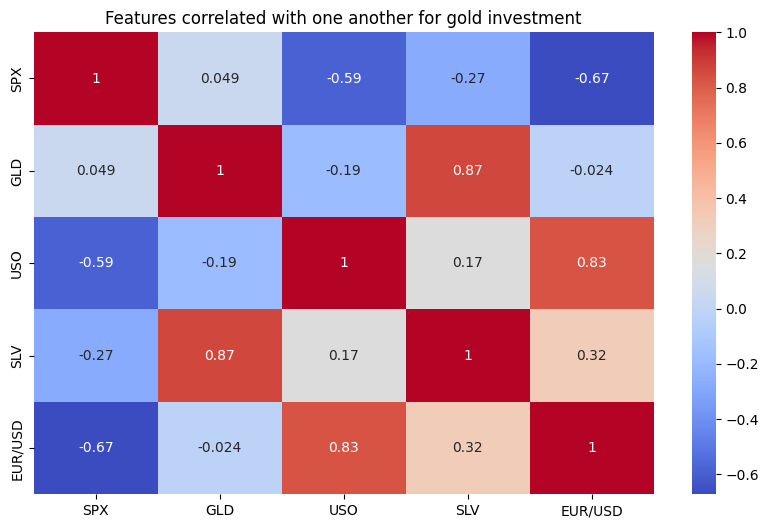

              SPX         GLD        USO      SLV
0     1447.160034   84.860001  78.470001  15.1800
1     1447.160034   85.570000  78.370003  15.2850
2     1411.630005   85.129997  77.309998  15.1670
3     1416.180054   84.769997  75.500000  15.0530
4     1390.189941   86.779999  76.059998  15.5900
...           ...         ...        ...      ...
2285  2671.919922  124.589996  14.060000  15.5100
2286  2697.790039  124.330002  14.370000  15.5300
2287  2723.070068  125.180000  14.410000  15.7400
2288  2730.129883  124.489998  14.380000  15.5600
2289  2725.780029  122.543800  14.405800  15.4542

[2290 rows x 4 columns]
0       1.471692
1       1.474491
2       1.475492
3       1.468299
4       1.557099
          ...   
2285    1.186789
2286    1.184722
2287    1.191753
2288    1.193118
2289    1.182033
Name: EUR/USD, Length: 2290, dtype: float64
1: 0.7614120297197526
2: 0.751702176929789
3: 0.05375623036908899
4: 0.055404620183897774


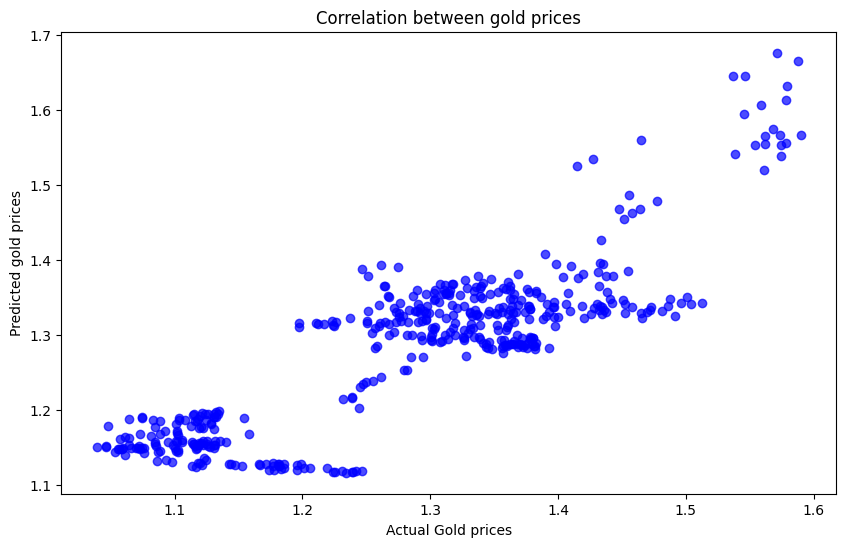

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
'''Gold prices can change really quickly, which makes it tricky for people who want to invest wisely. For someone who’s planning to save up for something big, like a new house or a car, predicting these changes could make a huge difference in how much they can save.

You can help by creating a smart program that predicts gold prices using previous data that’s stored in a dataset. By using a method called Linear Regression, your program can look at past gold prices and make educated guesses about what the price might be in the future. This way, people can make better decisions about when to buy or sell their gold.

Can you create this prediction tool to help others invest in gold more wisely?



Link for the dataset :

https://drive.google.com/file/d/1hwov5ZvDosXPIeMI_3QSqIyiMdprBk3F/view



HINT:



Data Loading and Initial Exploration:

The script begins by importing necessary libraries such as NumPy, pandas, Matplotlib, Seaborn, and Scikit-learn.
The dataset is loaded into a pandas DataFrame from a CSV file. The 'Date' column is converted to a datetime object, which is useful for time-series analysis.
Basic exploration is performed by printing the dataset, checking the shape, and verifying if there are any missing values.
Statistical Analysis:

The script provides statistical measures of the dataset, which summarize key metrics like mean, median, standard deviation, etc., for each column.
A correlation matrix is generated to understand the relationships between different features (excluding the 'Date' column). Positive and negative correlations help identify which features are most related to the EUR/USD exchange rate.
A heatmap is constructed using Seaborn to visually represent the correlation matrix, highlighting which features are strongly correlated with one another.
Data Splitting:

The feature set X is created by dropping the 'EUR/USD' and 'Date' columns, while the target variable Y is the 'EUR/USD' column.
The dataset is split into training and testing sets, with 80% of the data used for training and 20% reserved for testing. This split allows for model validation on unseen data.
Model Training:

A Linear Regression model is instantiated and trained on the training data (X_train and Y_train). This model will learn the relationship between the input features and the EUR/USD exchange rate.
Model Evaluation:

Predictions are made on the training data to evaluate the model's performance.
The R-squared (R²) error and Mean Absolute Error (MAE) are calculated. R² indicates how well the model's predictions fit the actual data, while MAE measures the average magnitude of errors in the predictions.
The model is then tested on the test set (X_test), and the same evaluation metrics (R² and MAE) are computed to assess how well the model generalizes to new, unseen data.
Results:

The R² and MAE values for both training and testing data are printed, which helps in understanding the model's accuracy and reliability.
Repeated printing of these metrics indicates multiple checks for consistency and reliability of the results.
'''
# initial basics
df = pd.read_csv("/kaggle/input/gold-csv/gld.csv")
print(df.head())
print()
print(df.isnull().sum())
print()
print(df.shape)
print()
print(df.info())
print()
print(df.describe())
print()

df = df.drop(columns = "Date")
print(df.head())

#heatmap
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(),annot = True,cmap = "coolwarm")
plt.title("Features correlated with one another for gold investment")
plt.show()

# X and Y determining
X = df.drop(['EUR/USD'], axis = 1)
Y = df['EUR/USD']
print(X)
print(Y)

#train test and splitting
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

#model prediction
model = LinearRegression()
model.fit(X_train, Y_train)

#model predictions
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

# MAE and R2
print("1:",r2_score(Y_train, Y_train_pred))
print("2:",r2_score(Y_test, Y_test_pred))
print("3:",mean_absolute_error(Y_train, Y_train_pred))
print("4:",mean_absolute_error(Y_test, Y_test_pred))

#visualization
plt.figure(figsize = (10,6))
plt.scatter(Y_test, Y_test_pred, alpha = 0.7, color = "blue")
plt.xlabel("Actual Gold prices")
plt.ylabel("Predicted gold prices")
plt.title("Correlation between gold prices")
plt.show()
